<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/We_logo.svg/3840px-We_logo.svg.png" alt="WE Logo" width="60" style="margin-bottom:8px"/>

# Telecom Egypt (WE) — ML Project
## Smart Plan Recommendation System

---

### Background

Telecom Egypt (WE) serves thousands of subscribers across Egypt with internet plans that vary in speed, quota, and price. A key business challenge is **plan-subscriber mismatch** — subscribers enrolled in plans that do not reflect their actual usage and payment behavior.

This project simulates a real-world data science task at WE. You are part of the Data & AI team. Your mission is to build a machine learning model that analyzes subscriber profiles and recommends the most suitable plan action:

> **Upgrade** — the subscriber needs a bigger plan  
> **Downgrade** — the subscriber is over-paying for what they use  
> **Keep** — the current plan is a good fit

---

### Available Datasets

| Dataset | Description |
|---------|-------------|
| `Customer.csv` | Subscriber demographics and plan enrollment |
| `Subscription_Plan_Lkp.csv` | Plan details — quota, speed, and price |
| `Network_Elements.csv` | Infrastructure type per subscriber (VDSL, FTTH, etc.) |
| `Payments.csv` | Monthly payment transactions per subscriber |
| `Consumption_RG_LKP.csv` | Lookup table for consumption rating groups |

---

### General Instructions

- Read each step carefully before writing any code.
- Each step has a clear objective — understand **why** you are doing it, not just **how**.
- You are expected to make decisions along the way. Document your reasoning in markdown cells.
- There is no single correct answer — justify your choices.


---
## Step 1 — Load & Explore the Data

### Objective
Understand what data you have before touching it.

### Why This Step Matters
Before building any model, a data scientist must fully understand the data — its structure, quality, and distributions. Skipping EDA leads to wrong assumptions and poor models.

### What To Do
- Load all 5 datasets and print their shape and data types.
- Check for missing values in each table and decide how to handle them.
- Visualize key distributions:
  - `Customer`: `SUBSCRIBER_STATUS`, `CUSTOMER_CLASS`, `GENDER`
  - `Subscription_Plan_Lkp`: price range, speed range, quota sizes
  - `Payments`: revenue columns and monthly revenue trend
  - `Network_Elements`: breakdown of `TECHNOLOGY_TYPE`

**Expected Output:** At least 4 visualizations. Write a short observation below each one explaining what you see.


Mounted at /content/drive


In [4]:
# -- Imports --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sns.set_style("whitegrid")
#Convert a QUOTA value like '400' or '1TB' into a number of GB
def parse_quota(q):
    q = str(q).strip().upper()
    if "TB" in q:
        return float(q.replace("TB", "")) * 1024
    return float(q)


In [5]:
from google.colab import drive
import os
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Data For Task 2'

# -- Load Data --
filenames = {
    "customer": "Customer.csv",
    "plans": "Subscription_Plan_Lkp.csv",
    "payments": "Payments.csv",
    "network": "Network_Elements.csv",
    "consumption": "Consumption_RG_LKP.csv",
}

tables = {}
for name, fname in filenames.items():
    tables[name] = pd.read_csv(os.path.join(file_path, fname))
    print(f"{name}: shape={tables[name].shape}")
    print(tables[name].dtypes)
    print("-" * 50)

customer = tables["customer"]
plans = tables["plans"]
payments = tables["payments"]
network = tables["network"]
consumption = tables["consumption"]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
customer: shape=(9995, 17)
SUBSCRIBER_ID#                    int64
ACCOUNT_ID#                       int64
CUSTOMER_ID#                      int64
GROUP_ID#                       float64
NAME                             object
SUBSCRIBER_STATUS                object
STATUS_DATE                      object
GENDER                           object
BIRTHDATE                        object
ID_TYPE                          object
NATIONALITY                      object
ACTIVATION_DATE                  object
CUSTOMER_CLASS                   object
SUBSCRIBER_TYPE                  object
SUBSCRIPTION_PLAN_FAMILY_ID#      int64
SUBSCRIPTION_PLAN_ID#             int64
SERVICE_NUMBER#                   int64
dtype: object
--------------------------------------------------
plans: shape=(108, 11)
SUBSCRIPTION_PLAN_ID#                    int64
SUBSCRIPTION_PLAN_FAMILY_ID# 

In [6]:
# -- Missing Values --
for name, tbl in tables.items():
    missing = tbl.isna().sum()
    missing = missing[missing > 0]
    print(f"{name} missing values:")
    print(missing if len(missing) else "  none")
    print()


customer missing values:
GROUP_ID#    9320
BIRTHDATE      61
dtype: int64

plans missing values:
  none

payments missing values:
  none

network missing values:
CENTRAL_NAME    30
dtype: int64

consumption missing values:
  none



# most subscribers are Active, class B/B+ dominate, gender is 50/50.

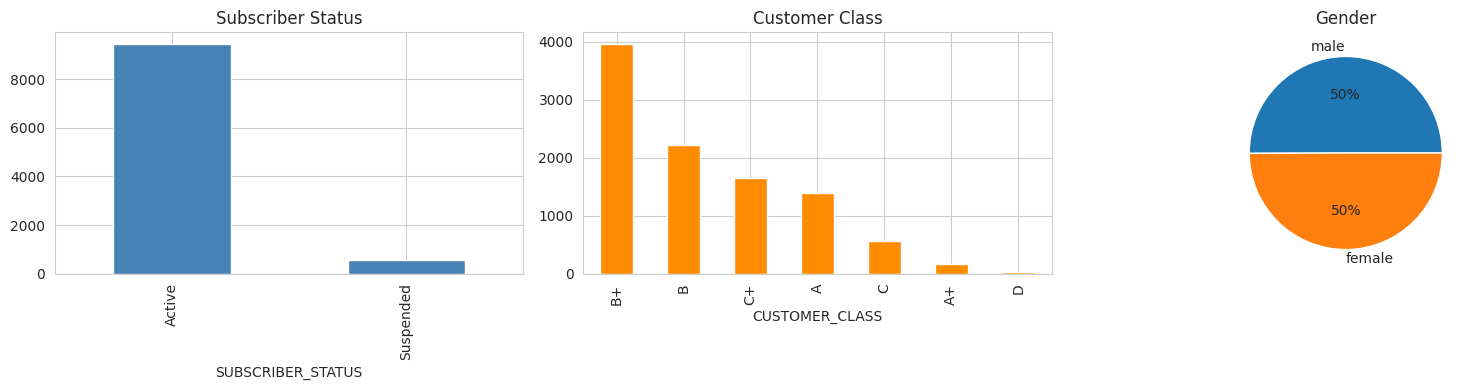

In [7]:
# -- EDA: Customer Table --
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

customer["SUBSCRIBER_STATUS"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Subscriber Status")

customer["CUSTOMER_CLASS"].value_counts().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Customer Class")

customer["GENDER"].value_counts().plot(kind="pie", ax=axes[2], autopct="%1.0f%%")
axes[2].set_title("Gender")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


# prices and quotas are both right-skewed
# plans (high GB, high price) sit far above the bulk of standard plans.

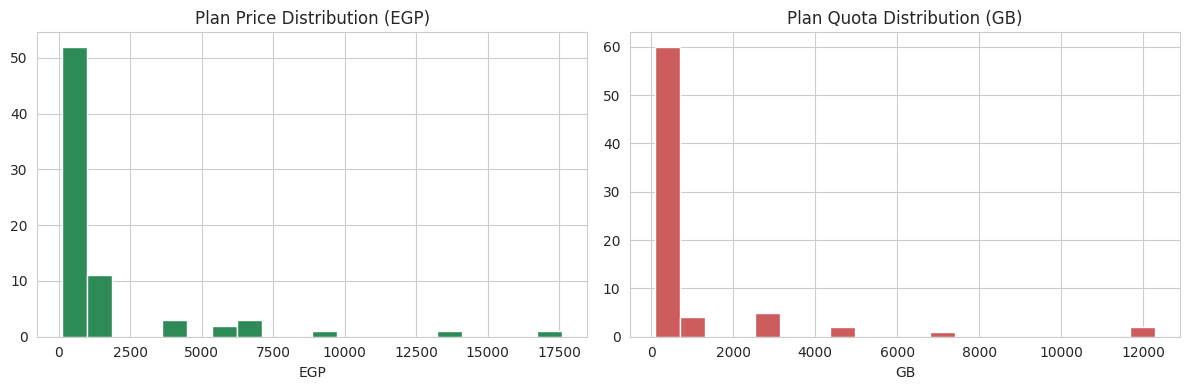

In [8]:
# -- EDA: Plans Table --
active_plans = plans[plans["PRICE_PLAN_PRICE"] > 0].copy()
active_plans["QUOTA_NUM"] = active_plans["QUOTA"].apply(parse_quota)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(active_plans["PRICE_PLAN_PRICE"], bins=20, color="seagreen")
axes[0].set_title("Plan Price Distribution (EGP)")
axes[0].set_xlabel("EGP")

axes[1].hist(active_plans["QUOTA_NUM"], bins=20, color="indianred")
axes[1].set_title("Plan Quota Distribution (GB)")
axes[1].set_xlabel("GB")

plt.tight_layout()
plt.show()



# revenue per subscriber is right-skewed with a long tail of big
# spenders, monthly revenue is fairly stable over time, and VDSL is by far the
# most common network technology.

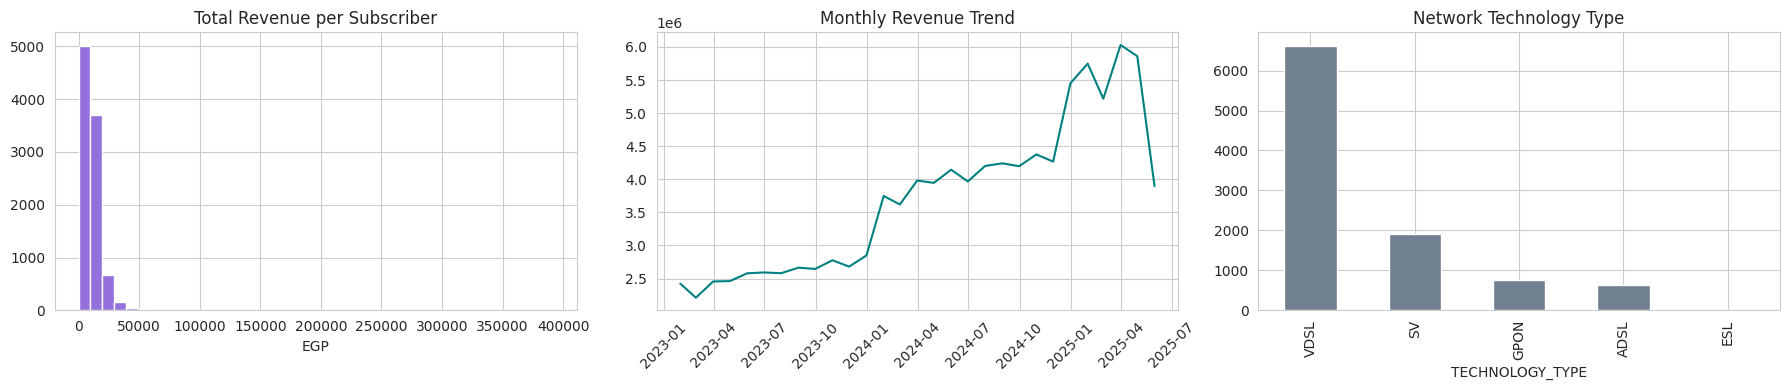

In [9]:
# -- EDA: Payments Table & Network Table --
payment_cols = ["RENT_REVENUE", "OUT_BUNDLE_REVENUE", "CREATION_FEES_REVENUE",
                "DEVICES_REVENUE", "IN_BUNDLE_REVENUE", "ADDON_REVENUE", "TAX_AMOUNT"]
payments["total_payment"] = payments[payment_cols].sum(axis=1)
payments["CONNECT_DATE"] = pd.to_datetime(payments["CONNECT_DATE"])

sub_totals = payments.groupby("SUBSCRIBER_ID#")["total_payment"].sum()
monthly_rev = payments.set_index("CONNECT_DATE")["total_payment"].resample("ME").sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(sub_totals, bins=40, color="mediumpurple")
axes[0].set_title("Total Revenue per Subscriber")
axes[0].set_xlabel("EGP")

axes[1].plot(monthly_rev.index, monthly_rev.values, color="teal")
axes[1].set_title("Monthly Revenue Trend")
axes[1].tick_params(axis="x", rotation=45)

network["TECHNOLOGY_TYPE"].value_counts().plot(kind="bar", ax=axes[2], color="slategray")
axes[2].set_title("Network Technology Type")

plt.tight_layout()
plt.show()


---
## Step 2 — Join the Tables

### Objective
Build a single unified subscriber profile by merging all relevant tables.

### Why This Step Matters
Real-world data is never in one place. The ability to correctly join tables — using the right keys and avoiding duplicates or row explosions — is a core data engineering skill.

### What To Do
- Start from `Customer.csv` as the base table.
- Join `Subscription_Plan_Lkp` on `SUBSCRIPTION_PLAN_ID#` → adds quota, speed, price.
- Join `Network_Elements` on `SERVICE_NUMBER#` → adds technology type.
- Aggregate `Payments` per subscriber, then join on `SUBSCRIBER_ID#`.
- After each join, verify the row count has not changed unexpectedly.

> **Watch out for:** Duplicate plan IDs in the lookup table — handle them before joining to avoid inflating your row count.


In [10]:
# -- Clean Plans --
plans_clean = plans.drop_duplicates(subset="SUBSCRIPTION_PLAN_ID#").copy()
plans_clean["QUOTA_NUM"] = plans_clean["QUOTA"].apply(parse_quota)
plans_clean = plans_clean[["SUBSCRIPTION_PLAN_ID#", "SUBSCRIPTION_PLAN_DESC",
                            "QUOTA_NUM", "SPEED", "PRICE_PLAN_PRICE"]]

print(f"Plans before cleaning: {plans.shape[0]}, after de-duping: {plans_clean.shape[0]}")


Plans before cleaning: 108, after de-duping: 108


In [11]:
# -- Join Plans --
df = customer.merge(plans_clean, on="SUBSCRIPTION_PLAN_ID#", how="left")
print(f"Customer rows: {len(customer)}  ->  after joining plans: {len(df)}")


Customer rows: 9995  ->  after joining plans: 9995


In [12]:
# -- Join Network --
network_clean = network.drop_duplicates(subset="SERVICE_NUMBER#")[["SERVICE_NUMBER#", "TECHNOLOGY_TYPE"]]
df = df.merge(network_clean, on="SERVICE_NUMBER#", how="left")
print(f"After joining network: {len(df)}")


After joining network: 9995


In [13]:
# -- Aggregate Payments --
payment_agg = payments.groupby("SUBSCRIBER_ID#").agg(
    avg_monthly_rev=("total_payment", "mean"),
    total_revenue=("total_payment", "sum"),
    addon_total=("ADDON_REVENUE", "sum"),
    n_payments=("total_payment", "count"),
).reset_index()

df = df.merge(payment_agg, on="SUBSCRIBER_ID#", how="left")
print(f"After joining payments: {len(df)}")
print(f"Subscribers with no payment history: {df['avg_monthly_rev'].isna().sum()}")


After joining payments: 9995
Subscribers with no payment history: 363


---
## Step 3 — Feature Engineering

### Objective
Transform raw columns into meaningful features that help the model learn patterns.

### Why This Step Matters
Raw data rarely goes directly into a model. Feature engineering is where domain knowledge meets data science — the better your features, the better your model.

### Features To Create

| Feature | Formula | What It Captures |
|---------|---------|-----------------|
| `tenure_days` | `reference_date − ACTIVATION_DATE` | How long the subscriber has been active |
| `avg_monthly_rev` | Mean of payments per subscriber | Average spending per month |
| `addon_ratio` | `addon_total / total_revenue` | How often the subscriber exceeds their bundle |
| `price_to_quota_ratio` | `PRICE_PLAN_PRICE / QUOTA_NUM` | Cost per GB — how expensive the plan is relative to its size |

---

**Formula Details:**

**addon_ratio:**

$$\text{addon_ratio} = \frac{\text{ADDON_REVENUE}}{\text{total_revenue}}$$

*Example:* Subscriber paid 500 EGP total, 100 EGP was addon → addon_ratio = 100/500 = **0.20** (20% outside bundle)

---

**price_to_quota_ratio:**

$$\text{price_to_quota_ratio} = \frac{\text{PRICE_PLAN_PRICE}}{\text{QUOTA_NUM}}$$

*Example:* Plan costs 570 EGP for 400 GB → price_to_quota_ratio = 570/400 = **1.43 EGP per GB**

---

After creating each feature, print a `.describe()` and check for outliers or unexpected values.


In [14]:
# -- tenure_days --
reference_date = pd.Timestamp("2026-06-30")
df["ACTIVATION_DATE"] = pd.to_datetime(df["ACTIVATION_DATE"])
df["tenure_days"] = (reference_date - df["ACTIVATION_DATE"]).dt.days

print(df["tenure_days"].describe())


count    9995.000000
mean     2104.852126
std      1234.769266
min       409.000000
25%      1099.000000
50%      1966.000000
75%      2862.000000
max      8144.000000
Name: tenure_days, dtype: float64


In [18]:
# -- addon_ratio --
df["addon_ratio"] = (df["addon_total"] / df["total_revenue"]).fillna(0)

print(df["addon_ratio"].describe())


count    9995.000000
mean        0.027462
std         0.043191
min         0.000000
25%         0.000000
50%         0.013312
75%         0.031590
max         0.500000
Name: addon_ratio, dtype: float64


In [19]:
# -- price_to_quota_ratio --
df["price_to_quota_ratio"] = df["PRICE_PLAN_PRICE"] / df["QUOTA_NUM"]

print(df["price_to_quota_ratio"].describe())


count    9995.000000
mean        1.409352
std         0.632042
min         0.000000
25%         1.450000
50%         1.500000
75%         1.500000
max        44.785714
Name: price_to_quota_ratio, dtype: float64


In [20]:
# -- Summary: All Engineered Features --
engineered = ["tenure_days", "avg_monthly_rev", "addon_ratio", "price_to_quota_ratio"]
df[engineered].describe()


,tenure_days,avg_monthly_rev,addon_ratio,price_to_quota_ratio
count,9995.000000,9632.000000,9995.000000,9995.000000
mean,2104.852126,341.655027,0.027462,1.409352
std,1234.769266,262.739756,0.043191,0.632042
min,409.000000,10.000000,0.000000,0.000000
25%,1099.000000,226.707650,0.000000,1.450000
50%,1966.000000,303.333333,0.013312,1.500000
75%,2862.000000,376.666667,0.031590,1.500000
max,8144.000000,8925.000000,0.500000,44.785714


---
## Step 4 — Build the Target Variable

### Objective
Define the label the model will learn to predict.

### Why This Step Matters
In supervised ML, the quality of your label directly determines the quality of your model. Here, there is no pre-labeled column — you must define the business logic yourself.

### Labeling Logic

First, compute the **pay_ratio** — how much the subscriber actually pays relative to their plan price:

$$\text{pay_ratio} = \frac{\text{avg_monthly_rev}}{\text{PRICE_PLAN_PRICE}}$$

Then apply the following rules:

| Condition | Label |
|-----------|-------|
| `addon_ratio > 0.15` OR `pay_ratio > 1.30` | `Upgrade` — paying beyond their plan |
| `pay_ratio < 0.50` | `Downgrade` — consistently under-paying |
| Everything else | `Keep` — plan is a good fit |

**Examples:**

| Subscriber | Plan Price | Avg Monthly Pay | pay_ratio | addon_ratio | Label |
|-----------|-----------|----------------|-----------|-------------|-------|
| A | 400 EGP | 550 EGP | 1.375 → 137% | 0.05 | **Upgrade** |
| B | 400 EGP | 180 EGP | 0.450 → 45% | 0.01 | **Downgrade** |
| C | 400 EGP | 350 EGP | 0.875 → 87% | 0.08 | **Keep** |


---

After labeling: print the class distribution. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it.


In [21]:
# -- Compute pay_ratio --
df["pay_ratio"] = np.where(df["PRICE_PLAN_PRICE"] > 0,
                            df["avg_monthly_rev"] / df["PRICE_PLAN_PRICE"],
                            np.nan)

def label_subscriber(row):
    if pd.isna(row["pay_ratio"]):
        return np.nan
    if row["addon_ratio"] > 0.15 or row["pay_ratio"] > 1.30:
        return "Upgrade"
    elif row["pay_ratio"] < 0.50:
        return "Downgrade"
    else:
        return "Keep"

df["recommendation"] = df.apply(label_subscriber, axis=1)

print(df["pay_ratio"].describe())


count    9325.000000
mean        1.297293
std         0.479050
min         0.076389
25%         0.951681
50%         1.304482
75%         1.494581
max        13.146199
Name: pay_ratio, dtype: float64


recommendation
Upgrade      4782
Keep         4511
Downgrade      32
Name: count, dtype: int64
recommendation
Upgrade      51.3
Keep         48.4
Downgrade     0.3
Name: proportion, dtype: float64


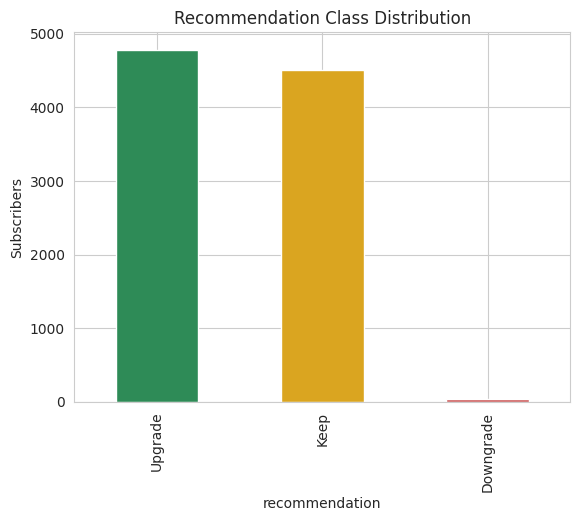

In [22]:
# -- Class Distribution --
print(df["recommendation"].value_counts())
print((df["recommendation"].value_counts(normalize=True) * 100).round(1))

df["recommendation"].value_counts().plot(kind="bar", color=["seagreen", "goldenrod", "indianred"])
plt.title("Recommendation Class Distribution")
plt.ylabel("Subscribers")
plt.show()


---
## Step 5 — Train & Compare Models

### Objective
Train multiple classifiers and understand the tradeoffs between them.

### Why This Step Matters
No single model is always best. A good data scientist knows when to use a simple interpretable model versus a complex one — and can justify that choice to a non-technical business stakeholder.

### Models To Train

| Model | Why |
|-------|-----|
| **Logistic Regression** | Your baseline — fast, interpretable, good for linear relationships |
| **Random Forest** | Handles non-linearity and feature interactions well |
| **Gradient Boosting** | Typically stronger performance but slower to train |

### Rules
- Use the same train/test/val split for all models `random_state=42`
- Print the Classification Report for each model
- Note any class where the model performs poorly and explain why in a markdown cell


In [23]:
# -- Select Features & Filter --
features = ["tenure_days", "avg_monthly_rev", "addon_ratio", "price_to_quota_ratio",
            "pay_ratio", "QUOTA_NUM", "SPEED", "PRICE_PLAN_PRICE",
            "CUSTOMER_CLASS", "GENDER", "TECHNOLOGY_TYPE", "SUBSCRIBER_TYPE"]

# Drop rows with no label (no payment history or free plans, where pay_ratio is undefined)
model_df = df.dropna(subset=["recommendation"])[features + ["recommendation"]].copy()

print(f"Rows available for modeling: {len(model_df)} out of {len(df)}")


Rows available for modeling: 9325 out of 9995


In [24]:
# -- Handle Missing Values --
num_cols = model_df.select_dtypes(include="number").columns
cat_cols = model_df.select_dtypes(include="object").columns.drop("recommendation")

model_df[num_cols] = model_df[num_cols].fillna(model_df[num_cols].median())
model_df[cat_cols] = model_df[cat_cols].fillna("Unknown")

print(f"{model_df.isna().sum().sum()} missing values remaining")


0 missing values remaining


In [25]:
# -- Encode Categorical Features --
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

target_encoder = LabelEncoder()
model_df["label"] = target_encoder.fit_transform(model_df["recommendation"])

print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


{'Downgrade': np.int64(0), 'Keep': np.int64(1), 'Upgrade': np.int64(2)}


In [26]:
# -- Train / Test Split --
X = model_df[features]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (7460, 12), Test: (1865, 12)


In [27]:
# -- Model 1: Logistic Regression (Baseline) --
log_reg = LogisticRegression(max_iter=800, random_state=42)
log_reg.fit(X_train, y_train)
pred_lr = log_reg.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, pred_lr, target_names=target_encoder.classes_))


Logistic Regression
              precision    recall  f1-score   support

   Downgrade       0.83      0.83      0.83         6
        Keep       0.98      0.97      0.97       902
     Upgrade       0.97      0.98      0.98       957

    accuracy                           0.97      1865
   macro avg       0.93      0.93      0.93      1865
weighted avg       0.97      0.97      0.97      1865



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
# -- Model 2: Random Forest --
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, pred_rf, target_names=target_encoder.classes_))


Random Forest
              precision    recall  f1-score   support

   Downgrade       1.00      1.00      1.00         6
        Keep       1.00      1.00      1.00       902
     Upgrade       1.00      1.00      1.00       957

    accuracy                           1.00      1865
   macro avg       1.00      1.00      1.00      1865
weighted avg       1.00      1.00      1.00      1865



In [29]:
# -- Model 3: Gradient Boosting --
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, pred_gb, target_names=target_encoder.classes_))


Gradient Boosting
              precision    recall  f1-score   support

   Downgrade       1.00      1.00      1.00         6
        Keep       1.00      1.00      1.00       902
     Upgrade       1.00      1.00      1.00       957

    accuracy                           1.00      1865
   macro avg       1.00      1.00      1.00      1865
weighted avg       1.00      1.00      1.00      1865



---
## Step 6 — Evaluate

### Objective
Measure model performance beyond just accuracy.


In [30]:
# -- Model Comparison --
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [accuracy_score(y_test, pred_lr), accuracy_score(y_test, pred_rf), accuracy_score(y_test, pred_gb)],
    "F1 (weighted)": [f1_score(y_test, pred_lr, average="weighted"),
                       f1_score(y_test, pred_rf, average="weighted"),
                       f1_score(y_test, pred_gb, average="weighted")],
})
print(results)

best_model_name = results.loc[results["F1 (weighted)"].idxmax(), "Model"]
print(f"\nBest model: {best_model_name}")


                 Model  Accuracy  F1 (weighted)
0  Logistic Regression  0.973727       0.973723
1        Random Forest  1.000000       1.000000
2    Gradient Boosting  1.000000       1.000000

Best model: Random Forest


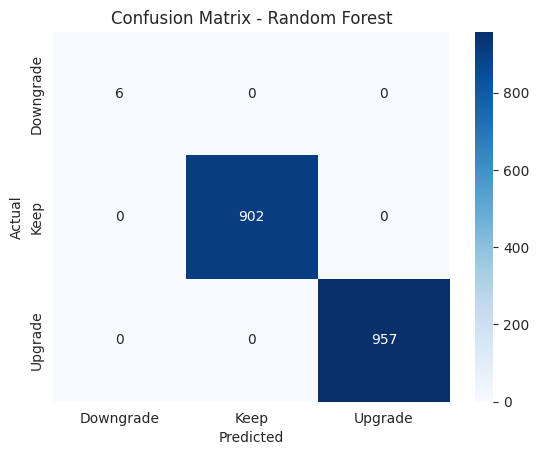

In [31]:
# -- Confusion Matrix (Best Model) --
models = {
    "Logistic Regression": (log_reg, pred_lr),
    "Random Forest": (rf, pred_rf),
    "Gradient Boosting": (gb, pred_gb),
}
best_model, best_pred = models[best_model_name]

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


---
## Step 7 — Business Impact

### Objective
Translate model predictions into actionable business recommendations.



In [32]:
# -- Predictions on Full Dataset --
X_full = model_df[features]
df.loc[model_df.index, "predicted_recommendation"] = target_encoder.inverse_transform(
    best_model.predict(X_full)
)

print(df["predicted_recommendation"].value_counts())


predicted_recommendation
Upgrade      4782
Keep         4511
Downgrade      32
Name: count, dtype: int64


In [33]:
# -- Revenue Opportunity --
upgrade_candidates = df[df["predicted_recommendation"] == "Upgrade"]
downgrade_candidates = df[df["predicted_recommendation"] == "Downgrade"]

potential_upgrade_revenue = (upgrade_candidates["avg_monthly_rev"] - upgrade_candidates["PRICE_PLAN_PRICE"]).clip(lower=0).sum()
potential_downgrade_risk = (downgrade_candidates["PRICE_PLAN_PRICE"] - downgrade_candidates["avg_monthly_rev"]).clip(lower=0).sum()

print(f"Subscribers flagged for Upgrade: {len(upgrade_candidates)}")
print(f"Estimated extra monthly revenue if upgraded: {potential_upgrade_revenue:,.0f} EGP")
print(f"Subscribers flagged for Downgrade: {len(downgrade_candidates)}")
print(f"Estimated monthly revenue at risk (over-priced for usage): {potential_downgrade_risk:,.0f} EGP")


Subscribers flagged for Upgrade: 4782
Estimated extra monthly revenue if upgraded: 743,796 EGP
Subscribers flagged for Downgrade: 32
Estimated monthly revenue at risk (over-priced for usage): 71,841 EGP


In [34]:
# -- Upgrade Candidates Profile --
profile_cols = ["CUSTOMER_CLASS", "TECHNOLOGY_TYPE", "SUBSCRIBER_TYPE"]
for col in profile_cols:
    print(f"\nUpgrade candidates by {col} (%):")
    print((upgrade_candidates[col].value_counts(normalize=True) * 100).round(1))

upgrade_candidates[["tenure_days", "avg_monthly_rev", "PRICE_PLAN_PRICE", "pay_ratio"]].describe()



Upgrade candidates by CUSTOMER_CLASS (%):
CUSTOMER_CLASS
B+    35.4
C+    23.5
B     21.0
A     10.8
C      7.9
A+     1.2
D      0.1
Name: proportion, dtype: float64

Upgrade candidates by TECHNOLOGY_TYPE (%):
TECHNOLOGY_TYPE
VDSL    63.9
SV      18.7
GPON     9.8
ADSL     7.5
Name: proportion, dtype: float64

Upgrade candidates by SUBSCRIBER_TYPE (%):
SUBSCRIBER_TYPE
Resedential        99.2
Non-Resedential     0.8
Name: proportion, dtype: float64


,tenure_days,avg_monthly_rev,PRICE_PLAN_PRICE,pay_ratio
count,4782.000000,4782.000000,4782.000000,4782.000000
mean,1837.658929,407.373214,253.638645,1.611842
std,1288.280605,226.670835,132.383929,0.465348
min,415.000000,56.000000,195.000000,0.266667
25%,797.000000,304.638095,210.000000,1.435562
50%,1355.500000,335.240275,210.000000,1.491657
75%,2757.750000,449.097826,290.000000,1.701580
max,8144.000000,7493.333333,5830.000000,13.146199
